# Linear Regression From Scratch (Theory)

In linear regression the goal is to find a linear function that best describes the relationship between input variables and the target variable. The model tries to find parameters that minimize the prediction error between the predicted values and the real values.

## $y = mx + b$

Where:
- $y$ - predicted value (output of the model)
- $x$ - input variable (feature)
- $m$ - weight (slope of the line: model parameter that determines how much X influence the prediction)
- $b$ - bias (intercept of the line: shifts the line up or down)

The model learns the values of w and b during training in order to minimize the prediction error.

## Error function:

The error function measures how well the model fits the data. It calculates the difference between the predicted values and the real values from the dataset. The goal of the model is to minimize this error during training (to fit data the best).

In linear regression we usually use **Mean Squared Error (MSE)** as the error function:

## $MSE = \frac{1}{n}\sum_{i=1}^{n}(y_{i}-(mx_{i}+b))^{2}$

Where:
- $n$ - number of samples in the dataset
- $y_{i}$ - real value from the dataset
- $(mx_{i}+b)$ - predicted value from the model

The error is squared to make all values positive and to penalize larger mistakes more strongly. The model adjusts its parameters (m and b) to minimize the value of this error function.

The training process tries to find parameters that minimize the error function and produce the best possible predictions.

## Mathematics behind

The goal of linear regression is to minimize the error function and obtain the lowest possible value of the Mean Squared Error (MSE). This means that the predicted values produced by the model should be as close as possible to the real values in the dataset.

To achieve this, the model must find the optimal parameters $m$ (weight) and $b$ (bias) in the linear equation:

## $y = mx + b$

To find the optimal values of $m$ and $b$, we calculate the partial derivatives of the error function with respect to each parameter. These derivatives show how the error changes when we slightly change the values of $m$ and $b$.

The partial derivatives point in the direction of the steepest ascent of the error. To minimize the error, we move in the opposite direction - the direction of the steepest descent. This process of updating the parameters step by step in the direction that reduces the error is called **gradient descent**.

### Gradient Descent:

## $\frac{\partial }{\partial m} = \frac{2}{n}\sum_{i=1}^{n}-x_{i}(y_{i}-(mx_{i}+b))$
## $\frac{\partial }{\partial b} = \frac{2}{n}\sum_{i=1}^{n}-(y_{i}-(mx_{i}+b))$

To control how big each step is in the direction of the steepest descent, we use a **learning rate**, usually denoted as $α$. The learning rate is a small positive number that multiplies the partial derivatives before subtracting them from the parameters:

## $m := m - \alpha \frac{\partial MSE}{\partial m}$
## $b := b - \alpha \frac{\partial MSE}{\partial b}$

Too small $α$ -> learning is slow

Too large $α$ -> may overshoot the minimum and fail to converge

By repeatedly applying these updates, the parameters gradually move toward the values that minimize the error function, producing the best-fitting line for the data.

# Linear Regression From Scratch (Python implementation)

In [1]:
#Imports
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
import numpy as np

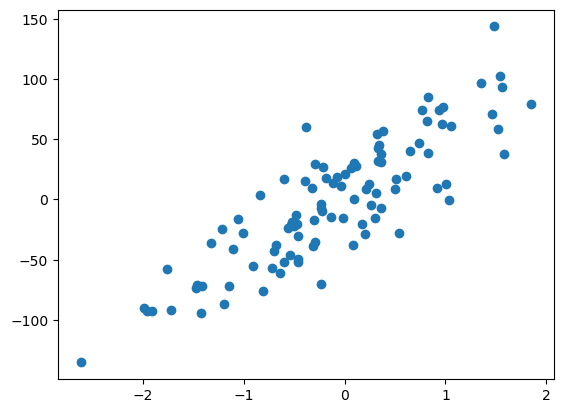

In [2]:
#Creating a simple dataset
X, y = make_regression(n_samples=100, n_features=1, noise=30, random_state=42)
df = pd.DataFrame({"x": X.flatten(), "y": y})

plt.scatter(df["x"],df["y"])
plt.show()

In [3]:
#Gradient descent
def grad_desc(m_now, b_now, df, L):
    m_gradient = 0
    b_gradient = 0

    n = len(df)

    for i in range(n):
        x = df["x"][i]
        y = df["y"][i]

        m_gradient += -(2/n) * x * (y - (m_now * x + b_now))
        b_gradient += -(2/n) * (y - (m_now * x + b_now))

    m = m_now - m_gradient * L
    b = b_now - b_gradient * L
    return m, b

In [4]:
#starting values:
m = 0
b = 0
L = 0.01
epochs = 150 #iterations

epoch: 0, m:0.8172224347343083, b:-0.03358508556517896


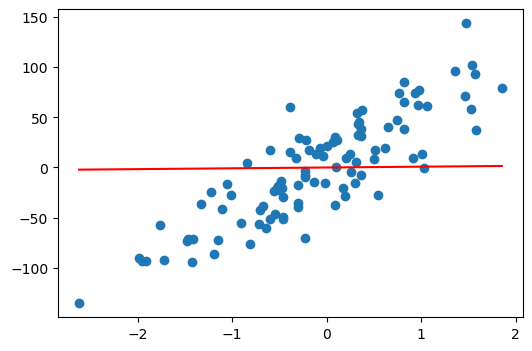

epoch: 50, m:28.28879164082951, b:0.134831933920948


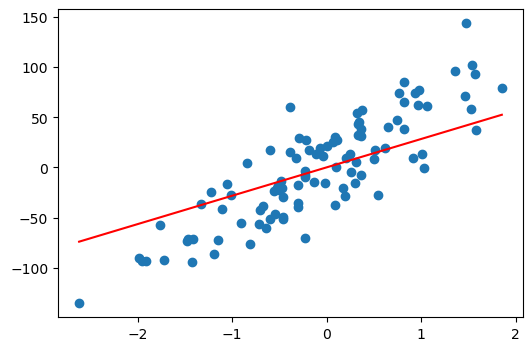

epoch: 100, m:40.286032849277255, b:1.355587393121778


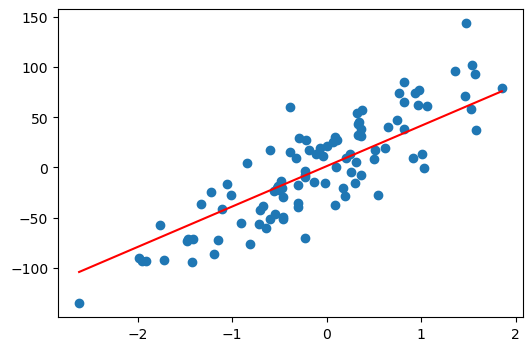

epoch: 150, m:45.5738080591173, b:2.3089226435601806


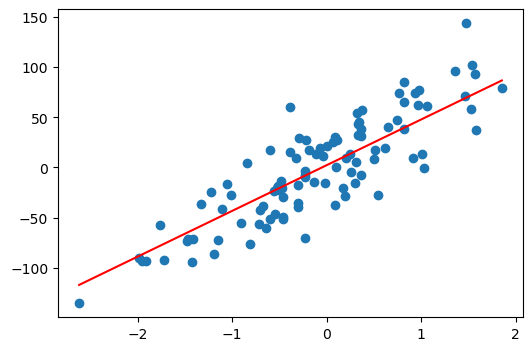

In [5]:
#training the model
for i in range(epochs+1):
    m, b = grad_desc(m, b, df, L)
    
    if i % 50 == 0:
        print(f"epoch: {i}, m:{m}, b:{b}")

        plt.figure(figsize=(6,4)) 
        plt.scatter(df["x"], df["y"])
        x_line = np.linspace(df["x"].min(), df["x"].max(), 100)
        y_line = m * x_line + b
        plt.plot(x_line, y_line, color="red")
        plt.show()